-BEGIN-

I will first code Parts A and B respectively. Then, I will answer the discussion questions in the bottom, as well as explain the algorithms, models, or code.

C0 error = 0.0000
C1 error = 0.0000
C2 error = 0.0000


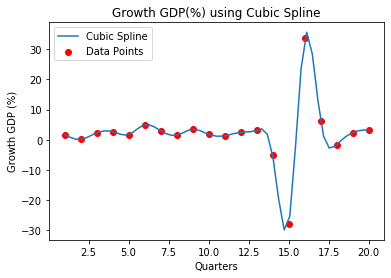

In [94]:
import numpy as np
import matplotlib.pyplot as plt



#Part A: Cubic Spline Interpolation
#I will first have an X and Y list to represent the data


X = np.arange(1, 21) #Using consecutive integer quarter indices for Quarters

Y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5,
            1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4,
             3.3]) #GDP Growth(%) from U.S. Bureau of Economic Analysis

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = (h[i-1]) # Subdiagonal
        B[i - 1] = (2*((h[i-1]) + h[i])) # Main diagonal
        C[i - 1] = (h[i]) # Superdiagonal
        D[i - 1] = (6*(((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1])))# Right-hand side vector
    return A, B, C, D


#The Thomas Algorithm will be used to solve the tridiagonal matrix
def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

#This function gives the natural spline boundary condition for Thomas algorith
def boundConThom(thomas):
    thomas = np.insert(thomas, 0, 0) #Inserts 0 at the end of the Thomas alg. output
    thomas = np.append(thomas, 0) #Insert 0 at start of the Thomas alg. output (Both are 0 for natural bound condition)
    
    return thomas

A, B, C, D = setup_tridiagonal_matrix(X, Y)
M = thomas_algorithm(A, B, C, D)
MBound = boundConThom(M)



#This function evaluates the spline that was given from the bounded Thomas algorithm.
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    
    S = (
    (M[i] / (6*hi)) * dx_right**3 + # Term 1
    (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
    (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
    (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

#Function evaluates the 1st derivative
def evaluate_spline_deriv1(x_data, y_data, M, x_query):
    """First derivative S'(x) of the natural cubic spline."""
    n = len(x_data)
    h = np.diff(x_data)
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    
    dS = (
       -(M[i]     / (2.0 * hi)) * dx_right**2
      + (M[i + 1] / (2.0 * hi)) * dx_left**2
      - (y_data[i]     / hi - M[i]     * hi / 6.0)
      + (y_data[i + 1] / hi - M[i + 1] * hi / 6.0)
    )
    return dS

#Function Evaluates 2nd Derivative
def evaluate_spline_deriv2(x_data, M, x_query):
    """Second derivative S'(x) of the natural cubic spline."""
    n = len(x_data)
    h = np.diff(x_data)
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)

    d2S = (M[i] / hi) * dx_right + (M[i + 1] / hi) * dx_left
    return d2S

eps = 1e-8   # small offset to approach from both sides
c0_errors, c1_errors, c2_errors = [], [], []
 
for k in range(1, len(X) - 1):       # interior knots x_1 … x_{n-2}
    xk = X[k]
    # Evaluate from the left interval (i = k-1) and the right interval (i = k)
    left_val  = evaluate_spline(X, Y, MBound, xk - eps)
    right_val = evaluate_spline(X, Y, MBound, xk + eps)
    left_d1   = evaluate_spline_deriv1(X, Y, MBound, xk - eps)
    right_d1  = evaluate_spline_deriv1(X, Y, MBound, xk + eps)
    left_d2   = evaluate_spline_deriv2(X, MBound, xk - eps)
    right_d2  = evaluate_spline_deriv2(X, MBound, xk + eps)
 
    c0_errors.append(abs(right_val - left_val))
    c1_errors.append(abs(right_d1  - left_d1))
    c2_errors.append(abs(right_d2  - left_d2))

#Check if for continuity condition, if they are all 0 then it is true.
print(f'C0 error = {max(c0_errors):.4f}')
print(f'C1 error = {max(c1_errors):.4f}')
print(f'C2 error = {max(c2_errors):.4f}')

xSpline = np.linspace(X[0], X[-1], 55)
ySpline = ([evaluate_spline(X, Y, MBound, val) for val in xSpline])

plt.scatter(X, Y, color='red', label='Data Points') 
plt.plot(xSpline, ySpline, label='Cubic Spline')    
plt.xlabel('Quarters')
plt.ylabel('Growth GDP (%)')
plt.title('Growth GDP(%) using Cubic Spline')
plt.legend()
plt.show()

Mean Squared Error: 99.3077
R-squared: 0.0166
Condition Number: 482958.7228348024
Polynomial RMSE: 9.9653
Cubic Spline RMSE: 0.0000


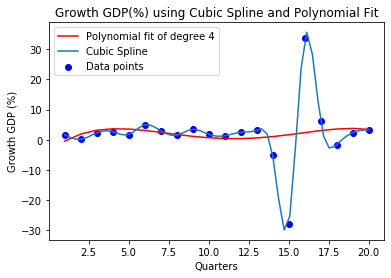

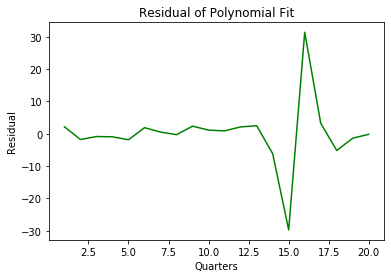

In [95]:
#Part B.1

#The Vandermonde for the Polynomial Fitting
def vandermondeMatrix (xList, n):
    vanderMatrix = []
    for x in xList:
        vanderRow = []
        for i in range(n+1):
            vanderRow.append(x**i)
            
        vanderMatrix.append(vanderRow)
    return np.array(vanderMatrix)

degree = 4 #Setting the degree = 4 according to Part B.1
V = vandermondeMatrix(X, degree)


# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, Y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients[::-1])
# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(X)

# Mean Squared Error (MSE)
mse = np.mean((Y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

#Condition number
conditionNumber = np.linalg.cond(V)
print(f'Condition Number: {conditionNumber}')

#Residual
residualsPoly = Y - y_pred

# RMSE for polynomial fit
rmse_poly = np.sqrt(np.mean((Y - y_pred)**2))
print(f'Polynomial RMSE: {rmse_poly:.4f}')

# RMSE for cubic spline (evaluated at the original data points)
y_spline_at_data = np.array([evaluate_spline(X, Y, MBound, xi) for xi in X])
rmse_spline = np.sqrt(np.mean((Y - y_spline_at_data)**2))
print(f'Cubic Spline RMSE: {rmse_spline:.4f}')

#I will use this as reference for the future
#Plotting both the cubic spline and polynomial fit to 4th degree
plt.scatter(X, Y, color='blue', label='Data points') # Original data points
plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.plot(xSpline, ySpline, label='Cubic Spline')    

plt.title('Polynomial Fit')
plt.xlabel('Quarters')
plt.ylabel('Growth GDP (%)')
plt.title('Growth GDP(%) using Cubic Spline and Polynomial Fit')
plt.legend()
plt.show()

plt.plot(X, residualsPoly, color = 'green', label = 'residuals')
plt.xlabel('Quarters')
plt.ylabel('Residual')
plt.title('Residual of Polynomial Fit')
plt.show()

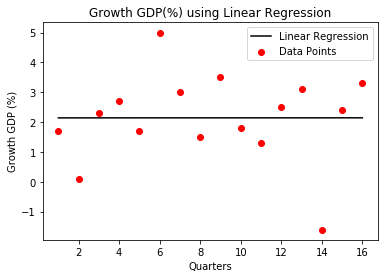

0.00014705882352961238


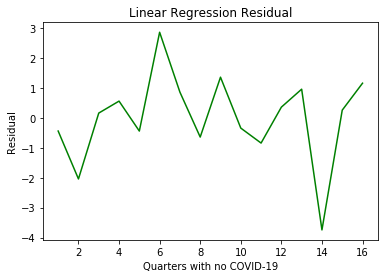

In [96]:
#Part B.2
#I will introduce the new data without COVID-19 Quarters
X = np.arange(1, 17) #Using consecutive integer quarter indices for Quarters

Y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5,
            1.8, 1.3, 2.5, 3.1, -1.6, 2.4,
             3.3]) #GDP Growth(%) from U.S. Bureau of Economic Analysis (Without COVID-19)

#This block of code is for the least squared method
def leastSquareMethod(X, Y): #Least squares linear regression using normal equations
    n = len(X)
    xSum = sum(X[i] for i in range(n))
    x2Sum = sum(X[i]**2 for i in range(n))
    ySum = sum(Y[i] for i in range(n))
    xySum = sum(Y[i]*X[i] for i in range(n))
    
    m = ((n*(xySum) - (xSum)*(ySum)))/(n*(x2Sum) - ((xSum)**2))
    c = (ySum - (m*xSum))/n
    
    return m, c #The "m" and "c" represent the slope and y-intercept, respectively


m, c = leastSquareMethod(X, Y) #Setting the slope and y-int. 

yLinear = m*X + c
residualsLinear = Y - yLinear

#Plotting the linear least square regression model
plt.scatter(X, Y, color='red', label='Data Points') 
plt.plot(X, m*X + c, color="black", label='Linear Regression')
plt.xlabel('Quarters')
plt.ylabel('Growth GDP (%)')
plt.title('Growth GDP(%) using Linear Regression')
plt.legend()
plt.show()

print(m)

plt.plot(X, residualsLinear, color = 'green', label = 'residuals')
plt.xlabel('Quarters with no COVID-19')
plt.ylabel('Residual')
plt.title('Linear Regression Residual')
plt.show()

**Introduction:**
    This notebook uses data for the growth of GDP(%) for the United States for multiple quarters from the year 2010 to 2023. The data was given by the U.S. Bureau of Economic Analysis, and the growth of GDP(%) is the seasonally adjusted annual rate. There will be an implementation of 3 different methods, those of which are: Cubic Spline Interpolation, Polynomial Fitting, and a Least Squares Linear Model. The Cubic Spline model will solve normal equations, have a tridiagonal matrix due to conditions, and be evaluated. The polynomial fit will use Vandermonde algorithm, while the linear model is linear regression of the data using Least Squares method.
    

**Part A:**
    We have to solve a tridiagonal system of linear equations for a cubic spline. There will be 4 unknown coefficients that need to be solved for the cubic spline. The number of unknowns will be n-2 second derivative for n points. The point, and first and second derivatives of the splines are continuous at the internal points. So, C0i(xi) = yi and C0i(x+1) = y+1, C1i(xi+1) = C1i+1(x+1) and C2i(xi+1) = C2i+1 The cubic spline can have two boundary conditions, a clamped spline cond. or a natural spline condition. This means S"(x1) = 0 and S"(xn) = 0 for natural spline; S'(x1) = f'(x1) and S'(xn) = f'(xn) for clamped. We will use the natural spline condition, where the second derivative at the endpoint is 0. This is because we do not have specifications on what the 1st derivative of the endpoints are

   The interpolant seems to be visually smooth given the 55 points of data. The only exception seems to be the point at X = 15 and X = 16 because they are outliers that came from COVID-19. The interpolation is also overall otherwise reasonable because the data is not noisy in those other sections.
    
   The trade-off between exact interpolation and numerical stability for datasets with extreme outliers would be that exact interpolation would lead to significantly weak numerical stability. The could be clearly shown with the Runge Phenomenon, where the exact fit (due also to a high degree polynomial) will have extreme oscillations for outliers within the usual data point range due to overfitting. If a weighted least squares were used to create a trendline, it would be more accurate to the general data points since it would not change drastically due to outliers. This is why it would be preferable to use weighted least squares, as they are much more robust against outliers and noise. On the other hand, cubic splines could also be used since they only go up to the 3rd degree, therefore they don't suffer from the Runge Phenomenon. This makes them viable for clean data. However, they should not be used with noisy data or extreme outliers since that will lead to a local distortion.

**Part B:** 
    The model that better captures the overall trend would be the polynomial fit. This is because the polynomial fit is more robust against outliers (in this case, the COVID-19 Quarters). However, the R-squared value is low and mean squared value is high, so the polynomial fit model is not great for interpolating between the data points. The Polynomial RMSE: 9.9653 and the Cubic Spline RMSE: 0.0000, therefore showing that the cubic spline is much better at interpolating between data points. So, the model that better reproduces specific data points would be the cubic spline fit model. This is because this model specifically interpolates each point with a cubic equation. Furthermore, their smoothness, continuity, and boundary conditions ensure accurate interpolation between clean data. However, the cubic spline is much more sensitive to noise data since the spline occurs between data points as opposed to a global equation.
    
   The slope is significantly small, however a linear trend does not make economic sense relative to the data. This is because GDP does not increase indefinitely, rather it can increase and decrease through cycles in the economy. Furthermore, the data points are far from the linear model, making it inaccurate. This linear model assumes that GDP growth will always increase as we move forward through quarters. This means that within 50 years, the  It also assumes that GDP growth will not be negative, which is false inherently within the context of economics since economics is cyclic in nature.
    
**Part C:**
    For a policymaker who need to estimate the GDP growth between two data points, cubic spline method would be more recommended for the data points that are not the outliers. This is because the smoothness that arises from the continuity and boundary conditions allow the cubic spline to be accurate between data points. However, due to the COVID-19 outlier, the cubic spline would not be accurate since it oscillates significant from the outliers. This is because the cubic spline is not robust. For these points, I would recommend the polynomial fit, since although they may not interpolate more accurately between other less noisy points, its robustness allows it to have a more accurate trend between the COVID-19 outliers. The condition number was also relatively low, around 482958, which is much less than 10^12 demonstrating that the polynomial fit solver is numerically stable. I would highly discourage using the polynomial fit, however, for other cleaner data points. This is because the mean squared error is high (99.3077) and the R-square value is extremely close to 0 (0.0166). The Polynomial RMSE: 9.9653, therefore proving even more that it is inaccurate for interpolating between clean data points.
Overall, this therefore leads to the conclusion that the polynomial fit is an inaccurate global model.
    
   Scalability is another factor that needs to be considered when discussing which algorithm/model to use. This factor usually refers to how well the algorithm can handle larger datasets through time and space. The time refers to how long it takes the algorithm to run in relation to the amount of data input. This is usually referred to as Big O/O(n), where "n" is the data inputs and the function depends on the time it takes. For example, if there were two for loops, Big O would be O(n^2) due to having to go through two loops. O(n) also relates to space, in which it refers to the amount of data that is kept. The most efficient one would be cubic spline, since it runs at O(n) due to the components making it up, such as the Thomas algorithm, are O(n). The polynomial fit, however, would be less efficient since it runs at O(n^2) due to the Vandermonde algorithm, which has 2 for loops. Furthermore, the dot product of the original matrix to the transposed matrix adds another degree, resulting the overall polynomial fit to be O(n^3) making it highly inefficient at larger scales.


Mean Squared Error: 99.3077
R-squared: 0.0166
Condition Number: 482958.7228348024
Polynomial RMSE: 9.9653
Cubic Spline RMSE: 0.0000

**Conclusion:**
    In conclusion, it would be better to use the cubic spline for data that is not noisy, however usage of the polynomial fit would be more suitable for trend analysis since it is more robust. Cubic spline, however, should try to be prioritized by cleaning data since it is more efficient with O(n) time compared to the polynomial fit of O(n^3). Overall, I learned that cubic spline is great for interpolating clean data, while polynomial fit is great for noisy data that and need a trend line.
